# Chapter 186 — Project: 3D Transformations

> **Prerequisites:** ch154 (matrix multiplication), ch164–ch168 (linear transformations, rotation, scaling, projection), ch173 (SVD), ch185 (matrix transformation playground — 2D)
> **Part VI Project** — Linear Algebra (chapters 151–200)
> **Difficulty:** Intermediate | **Estimated time:** 60–90 minutes
> **Output:** A 3D transformation pipeline: Euler rotations, homogeneous coordinates for affine transforms, camera projection, and a simple scene renderer

---

## 0. Overview

### Problem Statement

Computer graphics, robotics, and 3D data processing all require the same fundamental
operation: describing positions and orientations in 3D space and transforming them
via matrix multiplication.

The key insight: a $4 \times 4$ homogeneous matrix can encode rotation, scaling, and
translation in a single matrix multiply — making compositions of transformations trivial.
The same mathematics governs a robot's joint transforms, a camera's view matrix, and
a game engine's scene graph.

### Concepts Used
- 3D rotation matrices: Rx, Ry, Rz *(extends ch166)*
- Composition of transformations via matrix multiplication *(ch154)*
- Homogeneous coordinates: lifting $\mathbb{R}^3 \to \mathbb{R}^4$ for affine maps
- Perspective projection: a rank-1 update to the transform pipeline
- SVD as a decomposition of general 3D deformations *(ch173)*

### Expected Output
1. 3D rotation matrices: Rx, Ry, Rz and their composition
2. Homogeneous transform pipeline: translation + rotation + scaling in one matrix
3. Perspective projection: 3D → 2D
4. Scene rendering: a 3D wireframe cube under user-specified transforms
5. Gimbal lock demonstration — the failure mode of Euler angles

---

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

plt.style.use('seaborn-v0_8-whitegrid')

# ---------------------------------------------------------------
# Reference geometry: a unit cube centered at origin,
# a coordinate frame (axis arrows), and a simple 3D mesh.
# ---------------------------------------------------------------

def cube_vertices():
    """
    8 vertices of a unit cube centered at origin.
    Returns: shape (3, 8), each column is a vertex [x, y, z].
    """
    return np.array([
        [-1,-1,-1], [-1,-1, 1], [-1, 1,-1], [-1, 1, 1],
        [ 1,-1,-1], [ 1,-1, 1], [ 1, 1,-1], [ 1, 1, 1]
    ]).T   # shape (3, 8)


CUBE_VERTICES = cube_vertices()

# Cube edges: pairs of vertex indices
CUBE_EDGES = [
    (0,1),(0,2),(0,4),(1,3),(1,5),(2,3),(2,6),(3,7),
    (4,5),(4,6),(5,7),(6,7)
]

# Cube faces (for filled rendering)
CUBE_FACES = [
    [0,1,3,2], [4,5,7,6],   # left/right
    [0,1,5,4], [2,3,7,6],   # bottom/top
    [0,2,6,4], [1,3,7,5],   # front/back
]

print(f"Cube: {CUBE_VERTICES.shape[1]} vertices, {len(CUBE_EDGES)} edges, {len(CUBE_FACES)} faces")

Cube: 8 vertices, 12 edges, 6 faces


---

## 2. Stage 1 — 3D Rotation Matrices

In 2D, there is only one rotation axis (the z-axis out of the plane).
In 3D, we can rotate about any axis. The three elementary rotations:

$$\mathbf{R}_x(\theta) = \begin{pmatrix} 1 & 0 & 0 \\ 0 & \cos\theta & -\sin\theta \\ 0 & \sin\theta & \cos\theta \end{pmatrix}$$

$$\mathbf{R}_y(\theta) = \begin{pmatrix} \cos\theta & 0 & \sin\theta \\ 0 & 1 & 0 \\ -\sin\theta & 0 & \cos\theta \end{pmatrix}$$

$$\mathbf{R}_z(\theta) = \begin{pmatrix} \cos\theta & -\sin\theta & 0 \\ \sin\theta & \cos\theta & 0 \\ 0 & 0 & 1 \end{pmatrix}$$

Each is orthogonal ($\mathbf{R}^\top\mathbf{R} = \mathbf{I}$, $\det = 1$).

In [2]:
# --- Stage 1: 3D Rotation Matrices ---

def Rx(theta):
    """Rotation about x-axis by angle theta (radians)."""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[1, 0,  0],
                     [0, c, -s],
                     [0, s,  c]])

def Ry(theta):
    """Rotation about y-axis by angle theta (radians)."""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[ c, 0, s],
                     [ 0, 1, 0],
                     [-s, 0, c]])

def Rz(theta):
    """Rotation about z-axis by angle theta (radians)."""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s, 0],
                     [s,  c, 0],
                     [0,  0, 1]])


# Verify orthogonality
for name, R_fn in [('Rx', Rx), ('Ry', Ry), ('Rz', Rz)]:
    R = R_fn(np.pi / 3)
    err_ortho = np.linalg.norm(R.T @ R - np.eye(3))
    det_val   = np.linalg.det(R)
    print(f"{name}(60°): ||R^T R - I|| = {err_ortho:.2e},  det = {det_val:.6f}")


# --- Rotation composition is not commutative ---
ALPHA = np.pi / 4   # 45° x-rotation
BETA  = np.pi / 3   # 60° y-rotation

R1 = Rx(ALPHA) @ Ry(BETA)   # x first, then y
R2 = Ry(BETA) @ Rx(ALPHA)   # y first, then x

print(f"\nRx(45°) @ Ry(60°):\n{np.round(R1, 4)}")
print(f"\nRy(60°) @ Rx(45°):\n{np.round(R2, 4)}")
print(f"\nAre they equal? {np.allclose(R1, R2)}")
print(f"Max difference: {np.abs(R1 - R2).max():.4f}")

Rx(60°): ||R^T R - I|| = 2.10e-17,  det = 1.000000
Ry(60°): ||R^T R - I|| = 2.10e-17,  det = 1.000000
Rz(60°): ||R^T R - I|| = 2.10e-17,  det = 1.000000

Rx(45°) @ Ry(60°):
[[ 0.5     0.      0.866 ]
 [ 0.6124  0.7071 -0.3536]
 [-0.6124  0.7071  0.3536]]

Ry(60°) @ Rx(45°):
[[ 0.5     0.6124  0.6124]
 [ 0.      0.7071 -0.7071]
 [-0.866   0.3536  0.3536]]

Are they equal? False
Max difference: 0.6124


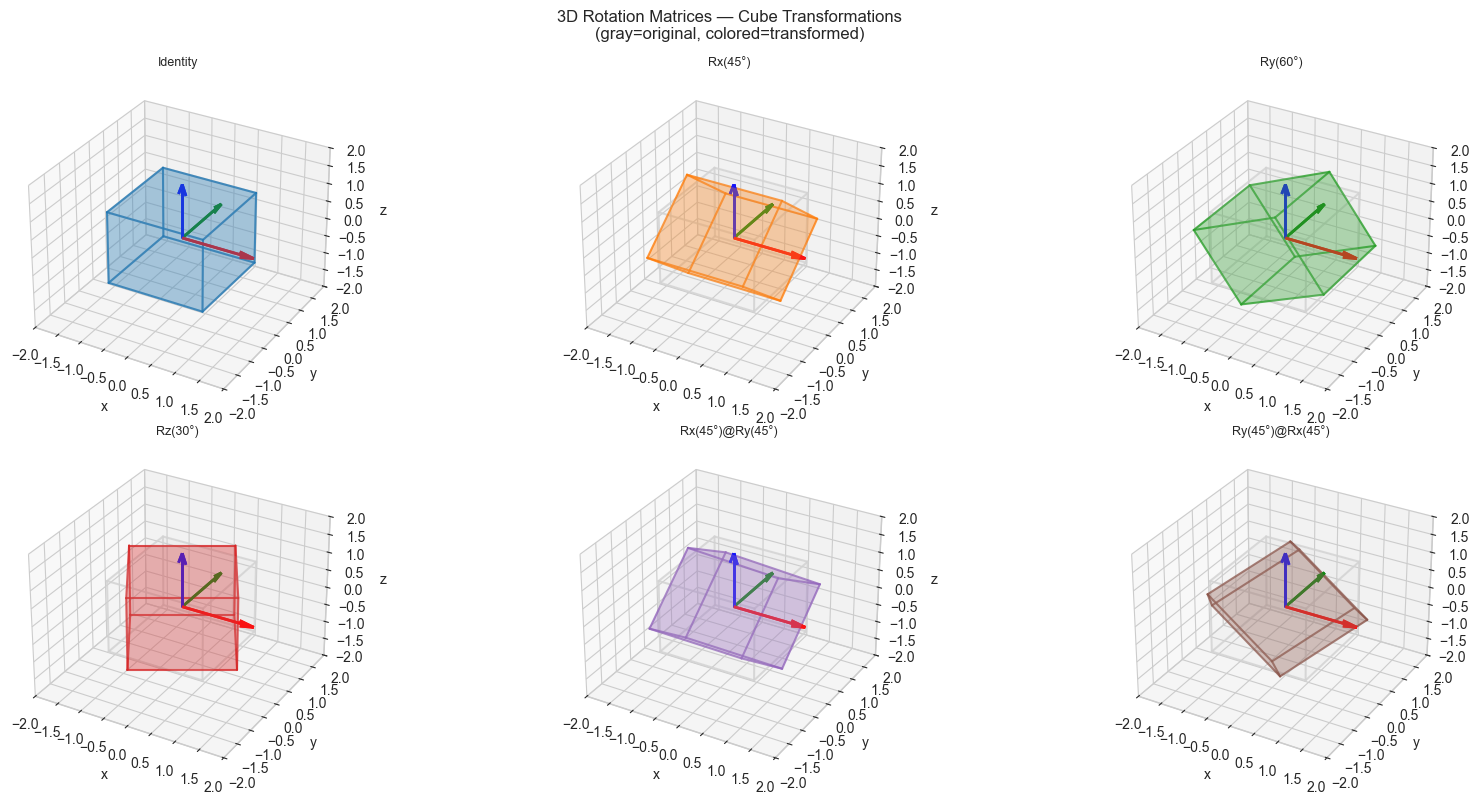

In [3]:
# --- Visualize cube under various rotations ---

def draw_cube(ax, vertices_3d, title='', color='steelblue', alpha=0.15):
    """
    Draw a 3D wireframe cube.

    Args:
        ax:          matplotlib 3D axes
        vertices_3d: shape (3, 8)
        title:       subplot title
    """
    # Draw edges
    for i, j in CUBE_EDGES:
        xs = [vertices_3d[0, i], vertices_3d[0, j]]
        ys = [vertices_3d[1, i], vertices_3d[1, j]]
        zs = [vertices_3d[2, i], vertices_3d[2, j]]
        ax.plot(xs, ys, zs, color=color, lw=1.5, alpha=0.8)

    # Draw faces
    face_verts = [[vertices_3d[:, idx].tolist() for idx in face]
                  for face in CUBE_FACES]
    poly = Poly3DCollection(face_verts, alpha=alpha,
                             facecolor=color, edgecolor='none')
    ax.add_collection3d(poly)

    # Draw coordinate axes (for the transformed frame)
    origin = np.zeros(3)
    for axis, col in [(np.array([1.5,0,0]),'red'),
                      (np.array([0,1.5,0]),'green'),
                      (np.array([0,0,1.5]),'blue')]:
        ax.quiver(*origin, *axis, color=col, arrow_length_ratio=0.2, lw=2)

    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_zlim(-2, 2)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.set_title(title, fontsize=9)


rotations = [
    (np.eye(3),              'Identity'),
    (Rx(np.pi/4),            'Rx(45°)'),
    (Ry(np.pi/3),            'Ry(60°)'),
    (Rz(np.pi/6),            'Rz(30°)'),
    (Rx(np.pi/4)@Ry(np.pi/4),'Rx(45°)@Ry(45°)'),
    (Ry(np.pi/4)@Rx(np.pi/4),'Ry(45°)@Rx(45°)'),
]

fig = plt.figure(figsize=(18, 8))
colors = plt.cm.tab10(np.arange(len(rotations)))

for i, (R, name) in enumerate(rotations):
    ax = fig.add_subplot(2, 3, i+1, projection='3d')
    verts_t = R @ CUBE_VERTICES
    draw_cube(ax, CUBE_VERTICES, title='', color='lightgray', alpha=0.05)
    draw_cube(ax, verts_t, title=name, color=colors[i], alpha=0.2)

plt.suptitle('3D Rotation Matrices — Cube Transformations\n(gray=original, colored=transformed)',
             fontsize=12)
plt.tight_layout()
plt.show()

---

## 3. Stage 2 — Homogeneous Coordinates and Affine Transforms

Pure rotation matrices cannot represent **translation** ($\mathbf{p} \mapsto \mathbf{p} + \mathbf{t}$)
as a matrix multiplication — translation is affine, not linear.

The fix: lift points to 4D by appending a $1$:
$\tilde{\mathbf{p}} = [x, y, z, 1]^\top$.

Then translation, rotation, and scaling all fit into a $4\times4$ matrix:

$$\mathbf{T} = \begin{pmatrix} \mathbf{R}_{3\times3} & \mathbf{t} \\ \mathbf{0}^\top & 1 \end{pmatrix}$$

Composing transforms is just matrix multiplication: $\mathbf{T}_2 \mathbf{T}_1 \tilde{\mathbf{p}}$.

Composed transform (scale→rotate→translate):
[[ 0.433  0.     0.25   2.   ]
 [ 0.     0.5    0.     0.5  ]
 [-0.25   0.     0.433 -1.   ]
 [ 0.     0.     0.     1.   ]]


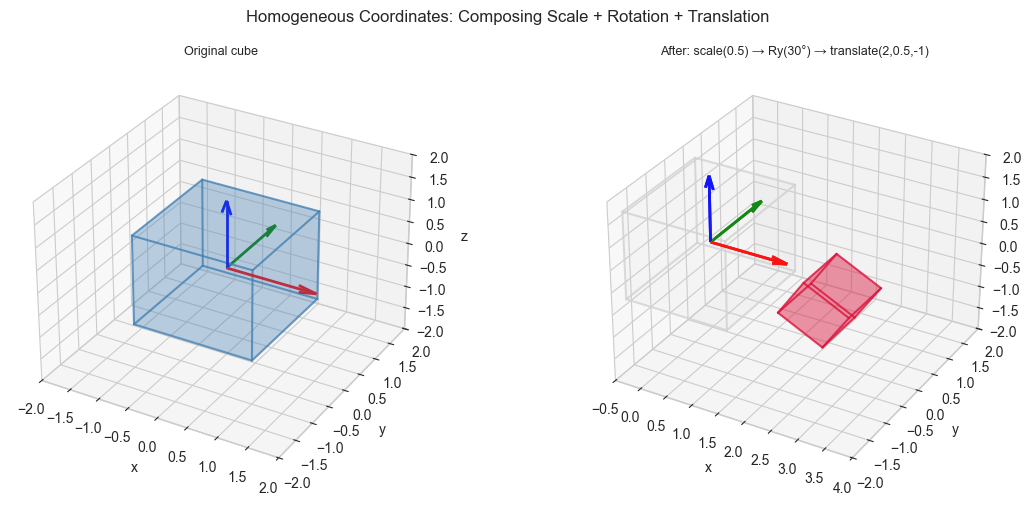


Roundtrip error: 4.44e-16


In [4]:
# --- Stage 2: Homogeneous Transform Pipeline ---

def make_transform(R=None, t=None, s=None):
    """
    Build a 4x4 homogeneous transformation matrix.

    T = [[s*R, t],
         [0,   1]]

    Args:
        R: 3x3 rotation matrix (default: identity)
        t: translation vector, shape (3,) (default: zero)
        s: uniform scale factor (default: 1)

    Returns:
        T: 4x4 homogeneous matrix
    """
    R = np.eye(3) if R is None else R
    t = np.zeros(3) if t is None else t
    s = 1.0 if s is None else s

    T = np.eye(4)
    T[:3, :3] = s * R
    T[:3,  3] = t
    return T


def apply_homogeneous(T, pts_3d):
    """
    Apply a 4x4 homogeneous transform to 3D points.

    Args:
        T:      4x4 homogeneous matrix
        pts_3d: 3D points, shape (3, N)

    Returns:
        Transformed 3D points, shape (3, N)
    """
    N = pts_3d.shape[1]
    pts_h = np.vstack([pts_3d, np.ones((1, N))])   # (4, N)
    pts_t = T @ pts_h                               # (4, N)
    return pts_t[:3] / pts_t[3]                     # dehomogenize


# Build a complex transform: scale → rotate → translate
T_scale  = make_transform(s=0.5)
T_rotate = make_transform(R=Ry(np.pi/6))
T_trans  = make_transform(t=np.array([2.0, 0.5, -1.0]))

# Compose: scale first, then rotate, then translate
# Note: apply right to left — T_trans @ T_rotate @ T_scale
T_composed = T_trans @ T_rotate @ T_scale

print("Composed transform (scale→rotate→translate):")
print(np.round(T_composed, 4))

# Apply to cube
CUBE_T = apply_homogeneous(T_composed, CUBE_VERTICES)

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection='3d')
draw_cube(ax1, CUBE_VERTICES, title='Original cube', color='steelblue', alpha=0.2)

ax2 = fig.add_subplot(122, projection='3d')
draw_cube(ax2, CUBE_VERTICES, title='', color='lightgray', alpha=0.05)
draw_cube(ax2, CUBE_T, title='After: scale(0.5) → Ry(30°) → translate(2,0.5,-1)',
          color='crimson', alpha=0.25)
ax2.set_xlim(-0.5, 4)
ax2.set_ylim(-2, 2)
ax2.set_zlim(-2, 2)

plt.suptitle('Homogeneous Coordinates: Composing Scale + Rotation + Translation', fontsize=12)
plt.tight_layout()
plt.show()

# Verify: the inverse transform should recover the original
T_inv    = np.linalg.inv(T_composed)
CUBE_rec = apply_homogeneous(T_inv, CUBE_T)
print(f"\nRoundtrip error: {np.abs(CUBE_rec - CUBE_VERTICES).max():.2e}")

---

## 4. Stage 3 — Perspective Projection: 3D to 2D

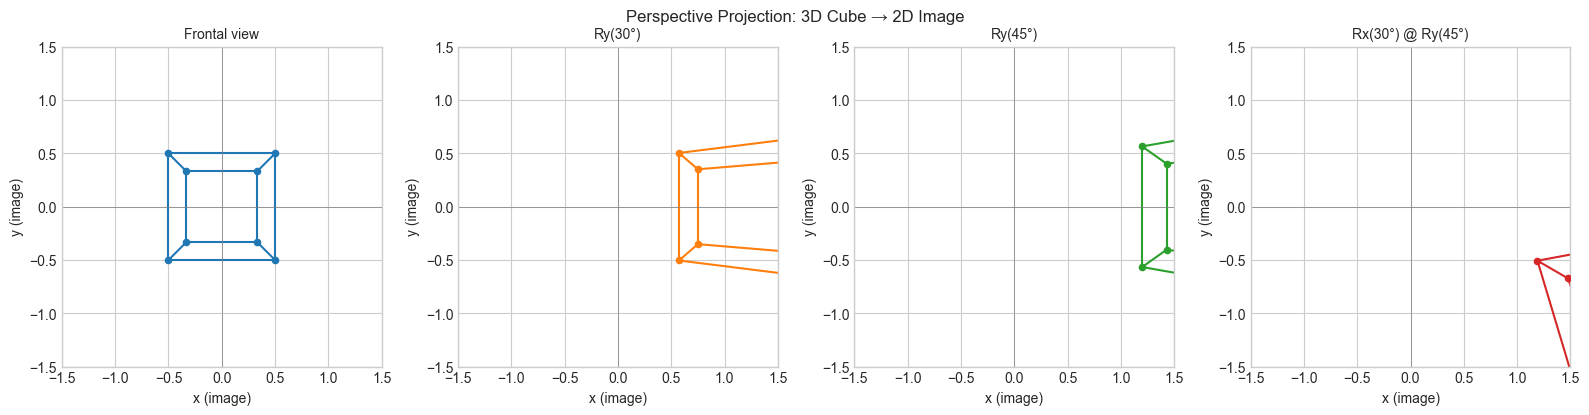

In [7]:
# --- Stage 3: Perspective Projection ---
#
# A pinhole camera at the origin looks down the +z axis.
# A 3D point [X, Y, Z] projects to image coordinates:
#     x_img = f * X / Z
#     y_img = f * Y / Z
# where f is the focal length.
#
# In homogeneous form, this is a 3x4 matrix (projection matrix P):
#     [f  0  0  0]
# P = [0  f  0  0]
#     [0  0  1  0]
#
# After multiplying, divide by the third homogeneous coordinate.

def perspective_project(pts_3d, focal_length=2.0):
    """
    Project 3D points onto a 2D image plane using perspective projection.

    Args:
        pts_3d:       3D points, shape (3, N)
        focal_length: focal length parameter f

    Returns:
        pts_2d: 2D image coordinates, shape (2, N)
    """
    f = focal_length
    P = np.array([[f, 0, 0, 0],
                  [0, f, 0, 0],
                  [0, 0, 1, 0]])
    N = pts_3d.shape[1]
    pts_h = np.vstack([pts_3d, np.ones((1, N))])   # (4, N)
    img_h = P @ pts_h                               # (3, N)
    pts_2d = img_h[:2] / img_h[2]                  # divide by depth
    return pts_2d


def draw_cube_2d(ax, pts_2d, title='', color='steelblue'):
    """Draw cube wireframe from 2D projected vertices."""
    for i, j in CUBE_EDGES:
        ax.plot([pts_2d[0, i], pts_2d[0, j]],
                [pts_2d[1, i], pts_2d[1, j]],
                color=color, lw=1.5)
    ax.scatter(*pts_2d, s=20, color=color, zorder=5)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('x (image)')
    ax.set_ylabel('y (image)')


# Place cube 5 units in front of camera, then rotate it
CUBE_WORLD = CUBE_VERTICES.copy().astype(float)
CUBE_WORLD[2] += 5.0   # translate cube along z (away from camera)

# Try different viewing angles
view_angles = [
    (np.eye(3), 'Frontal view'),
    (Ry(np.pi/6), 'Ry(30°)'),
    (Ry(np.pi/4), 'Ry(45°)'),
    (Rx(np.pi/6) @ Ry(np.pi/4), 'Rx(30°) @ Ry(45°)'),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors = plt.cm.tab10(np.arange(4))

for ax, (R, title), col in zip(axes, view_angles, colors):
    # Rotate the cube (or equivalently, rotate the camera)
    CUBE_ROT = R @ CUBE_WORLD
    CUBE_2D  = perspective_project(CUBE_ROT, focal_length=2.0)
    draw_cube_2d(ax, CUBE_2D, title=title, color=col)
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)

plt.suptitle('Perspective Projection: 3D Cube → 2D Image', fontsize=12)
plt.tight_layout()
plt.show()

---

## 5. Stage 4 — Gimbal Lock: The Failure Mode of Euler Angles

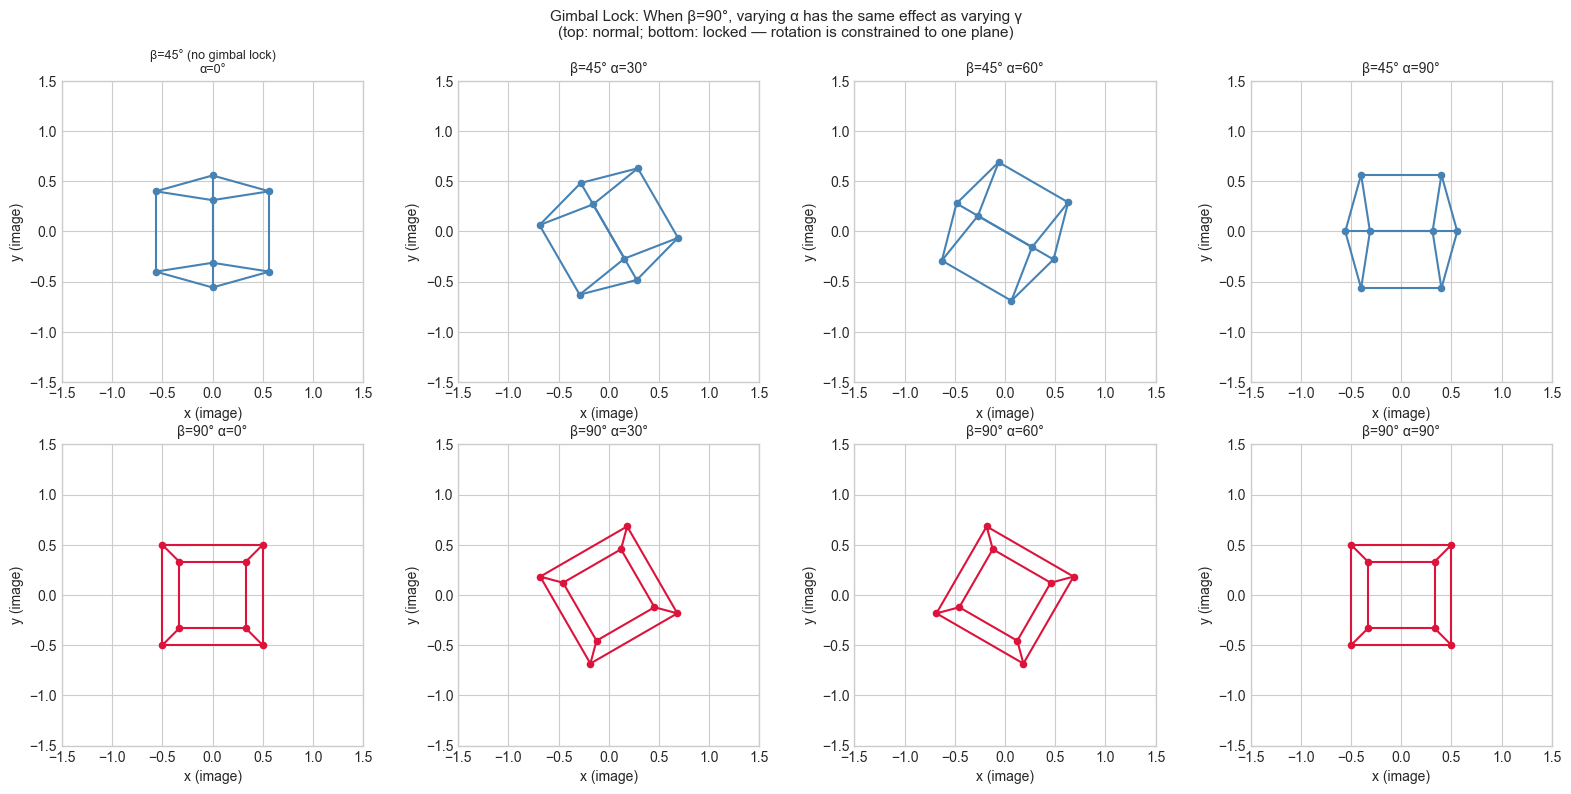


Gimbal lock numerical check:
At β=90°, R(α=30°, β=90°, γ=0°) should equal R(α=0°, β=90°, γ=-30°):
Max difference: 3.06e-17  (should be ~0)


In [8]:
# --- Stage 4: Gimbal Lock ---
#
# Euler angles: represent any rotation as three sequential single-axis rotations.
# Problem: when the middle rotation is +/-90 degrees, the first and third rotations
# collapse to the same axis — one degree of freedom is lost.
# This is "gimbal lock" — famous from the Apollo guidance computer.
#
# Hypothesis: rotating with Ry(90°) causes the x and z rotations to become equivalent.

def euler_to_matrix(alpha, beta, gamma):
    """
    Compose Euler angles (ZYX convention): Rz(alpha) @ Ry(beta) @ Rx(gamma)

    Args:
        alpha, beta, gamma: rotation angles in radians

    Returns:
        Combined 3x3 rotation matrix
    """
    return Rz(alpha) @ Ry(beta) @ Rx(gamma)


# Demonstrate gimbal lock: fix beta = pi/2
BETA_GIMBAL = np.pi / 2   # 90 degrees — the critical angle

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Row 0: normal rotation (beta = 45°)
# Row 1: gimbal lock (beta = 90°)
alpha_vals = [0, np.pi/6, np.pi/3, np.pi/2]
betas      = [np.pi/4, BETA_GIMBAL]

for row, beta_test in enumerate(betas):
    for col, alpha in enumerate(alpha_vals):
        R_euler = euler_to_matrix(alpha=alpha, beta=beta_test, gamma=0)
        CUBE_E = R_euler @ CUBE_VERTICES

        ax = axes[row, col]
        CUBE_2D = perspective_project(CUBE_E + np.array([[0],[0],[5]]), focal_length=2.0)
        draw_cube_2d(ax, CUBE_2D,
                     title=f'β={np.degrees(beta_test):.0f}° α={np.degrees(alpha):.0f}°',
                     color='steelblue' if row==0 else 'crimson')
        ax.set_xlim(-1.5, 1.5)
        ax.set_ylim(-1.5, 1.5)

axes[0, 0].set_title(f'β=45° (no gimbal lock)\nα={np.degrees(alpha_vals[0]):.0f}°', fontsize=9)

plt.suptitle('Gimbal Lock: When β=90°, varying α has the same effect as varying γ\n'
             '(top: normal; bottom: locked — rotation is constrained to one plane)',
             fontsize=11)
plt.tight_layout()
plt.show()

# Numerical confirmation: at beta=90, Rz(alpha) @ Ry(90) @ Rx(gamma)
# only depends on (alpha - gamma)
print("\nGimbal lock numerical check:")
print("At β=90°, R(α=30°, β=90°, γ=0°) should equal R(α=0°, β=90°, γ=-30°):")
R1 = euler_to_matrix(np.pi/6, np.pi/2, 0)
R2 = euler_to_matrix(0,       np.pi/2, -np.pi/6)
print(f"Max difference: {np.abs(R1 - R2).max():.2e}  (should be ~0)")

---

## 6. Results & Reflection

### What Was Built

A complete 3D transformation toolkit:
- Elementary rotation matrices Rx, Ry, Rz — all orthogonal with determinant 1
- Homogeneous coordinates: a $4 \times 4$ matrix encoding rotation + scale + translation in one multiply
- Perspective projection: the $3 \times 4$ projection matrix that maps 3D world coordinates to 2D image coordinates
- A 3D wireframe cube rendered from multiple viewpoints
- Gimbal lock: the algebraic reason why Euler angles lose a degree of freedom at $\beta = 90°$

### Core Insights

| Concept | What it reveals |
|---|---|
| Orthogonality of R | Rotations preserve lengths and angles: $\|\mathbf{R}\mathbf{v}\| = \|\mathbf{v}\|$ |
| Homogeneous coordinates | Translation is linear in augmented space — compose everything as matmuls |
| Perspective divide by Z | Closer objects appear larger — depth modulates the scale |
| Gimbal lock | Euler angles are not a smooth parameterization: quaternions solve this |

### Extension Challenges

**1. Quaternion rotation.**
Quaternions $q = w + xi + yj + zk$ with $|q|=1$ represent rotations without gimbal lock.
Implement quaternion multiplication and `quaternion_to_matrix`. Verify that quaternion
interpolation (slerp) produces smoother paths than Euler interpolation.

**2. Full rendering pipeline.**
Extend the perspective projection to a complete view frustum: model matrix → view matrix →
projection matrix → viewport transform. Render a more complex object (tetrahedron,
Stanford bunny point cloud) and implement backface culling using dot products with surface normals.

**3. Camera calibration basics.**
Given a set of known 3D points and their 2D projections, recover the camera intrinsic
matrix $\mathbf{K}$ and rotation/translation. This is the Direct Linear Transform (DLT)
algorithm — it is a least-squares problem *(ch182)* with an SVD solution *(ch173)*.

---

## Summary & Connections

- **3D rotation matrices** are orthogonal ($\mathbf{R}^\top = \mathbf{R}^{-1}$, $\det = 1$). They form the special orthogonal group SO(3). Composition by matrix multiplication is not commutative *(ch154)*.
- **Homogeneous coordinates** embed $\mathbb{R}^3 \hookrightarrow \mathbb{R}^4$ so that affine maps (translation + linear) become linear in the augmented space. This unifies the entire transform pipeline into a single $4 \times 4$ matmul *(ch154, ch164)*.
- **Perspective projection** is a linear map in homogeneous coordinates followed by a division by depth. The resulting non-linearity in Cartesian coordinates gives the visual effect of foreshortening.
- **Gimbal lock** is not a software bug — it is an intrinsic singularity of the Euler angle parameterization. Quaternions and rotation matrices do not have this problem.

**This project reappears in:**
- *ch119 (Geometry in Game Development)* — applies this exact pipeline in the context of game engines and scene graphs.
- *ch278 (Feature Engineering)* — 3D pose features for human motion data use the same rotation matrix representation.
- *ch187 (Project: Face Recognition PCA)* — face images are 2D projections of 3D objects; understanding this projection helps interpret what PCA captures.